In [1]:
import requests
import torch
from PIL import Image
from transformers import GroundingDino2ForObjectDetection, GroundingDino2Config, GroundingDino2Processor, GroundingDinoImageProcessor
from transformers import AutoTokenizer, CLIPImageProcessor, AutoProcessor
from typing import Tuple
from torch import Tensor
import matplotlib.pyplot as plt
from datasets import load_dataset
import albumentations as A
from typing import Any, Dict, List, Mapping, Tuple, Union
from transformers.image_processing_utils import BatchFeature
from functools import partial
import numpy as np
import random
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

In [2]:
image_processor = GroundingDinoImageProcessor()
tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-base-patch32")
semantic_processor = CLIPImageProcessor()

processor = GroundingDino2Processor(image_processor, tokenizer, semantic_processor)

/mnt/nas2/users/sbchoi/transformers/src/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## Query Image

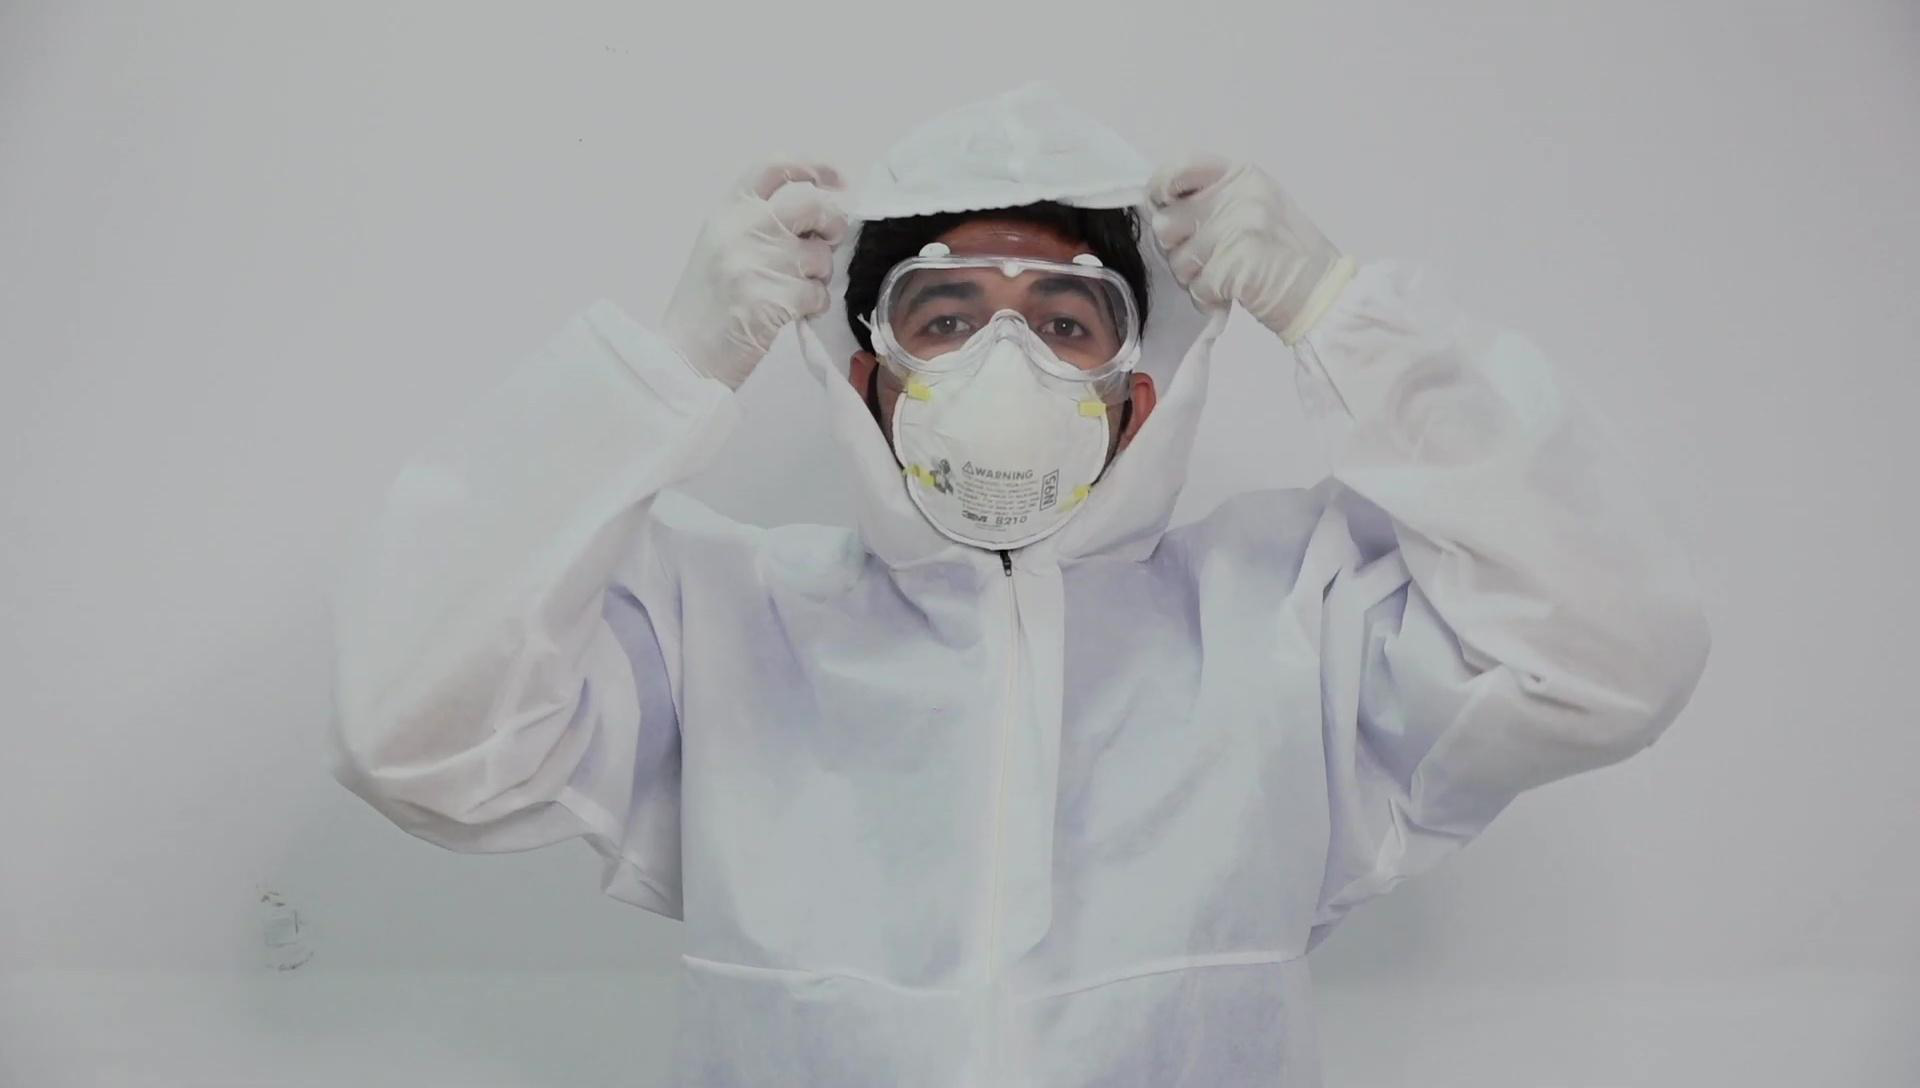

In [8]:
# Load image for inference
url = "https://datasets-server.huggingface.co/cached-assets/rishitdagli/cppe-5/--/66f6a5efd474e35bd7cb94bf15dea27d4c6ad3f8/--/default/test/0/image/image.jpg?Expires=1725504075&Signature=BKOcxbdJJ-eM3ttZY-lrS8b-KOEJxZ1NO4NKyB9zzTYdWja-INV2~ggl90sVAMeLfaxXTbDvYasKcu6h2tKfDATu22g8jKFAsnQ3cNmisuGNBf7~83gC7IT68b9SNl4lPf7l42PbRGZ59QTlGtVTHwuzZoHYvCy60zEHlUvBpOq3S~kpfgZZpRc3MTOlgn3KpMcBmWsqCkHTcr0Qt3n5OH97uL8TUbEY7NgKiXtr0JoOyDeeyRO5ODjGPCu5JKOqMdXLslsQGzZ7uolcsRH19jIbQLvKwpa8A0t7oKWLXj7rVGM6VVNuClHa-eLAhH83QCrqra6ZDEcuqiv0aCE-ig__&Key-Pair-Id=K3EI6M078Z3AC3"
# query_image = Image.open(requests.get(url, stream=True).raw)
query_image = Image.open('query_image.jpg')
query_image

## Search Image

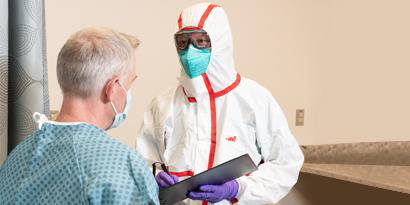

In [10]:
# Load image for inference
url = "https://datasets-server.huggingface.co/cached-assets/rishitdagli/cppe-5/--/66f6a5efd474e35bd7cb94bf15dea27d4c6ad3f8/--/default/test/1/image/image.jpg?Expires=1725504075&Signature=H1vQ1XCIjMWCS1HwZSKgwU7CEcmhGYS7lBBqoxJG6QKKRKksn2hqI4uPaMaGUu~S5opEZCUemf29X1CSF~zoj3KeTCgrkLlaX~qfjQHW5-I0NPthFD4eq1ue1znZNQsOlg5WhM5F2HOziIZnZmV8n5PdURWcCvO1UM8wK0FPdMGcGf4gx5mKClrB0vjblsUFhOJ99LGtwJZzmp8cgGkVx93~atPXZvHfmjq3xvO0NaarYtJkLXPJUEhpr0BY4gEAhkQDTGhqOriDRRnrXNEqA3oTIYBt0eNHn83z-nfgqpy8Ya-TrO4S3tBFl2HXsP46zxlSohQiiKH2-BTKUr1hIw__&Key-Pair-Id=K3EI6M078Z3AC3"
# search_image_1 = Image.open(requests.get(url, stream=True).raw)
search_image_1 = Image.open('search_image.jpg')
search_image_1

In [11]:
def crop_bboxes(image, bboxes):
    """
    Crop bounding boxes from a PIL image.

    Args:
        image (PIL.Image.Image): The input PIL image from which to crop the bounding boxes.
        bboxes (list of tuples): List of bounding boxes, where each bbox is represented as a tuple (x, y, w, h).

    Returns:
        list of PIL.Image.Image: List of cropped images corresponding to each bounding box.
    """
    cropped_images = []
    for (x, y, w, h) in bboxes:
        cropped_img = image[int(y):int(y+h),int(x):int(x+w)]
        cropped_images.append(cropped_img)
    
    return cropped_images

In [21]:
bbox = [ [ 868, 239, 279, 165 ], [ 890, 318, 219, 231 ], [ 654, 156, 196, 238 ], [ 1146, 152, 204, 194 ], [ 319, 79, 1392, 1008 ] ]
# bbox = [ [ 890, 318, 219, 231 ], ]
cropped_images = crop_bboxes(np.array(query_image.convert("RGB")), bbox)

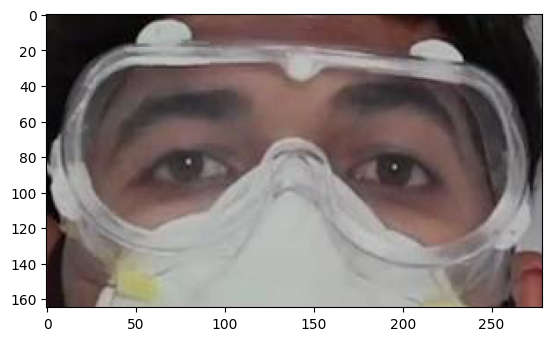

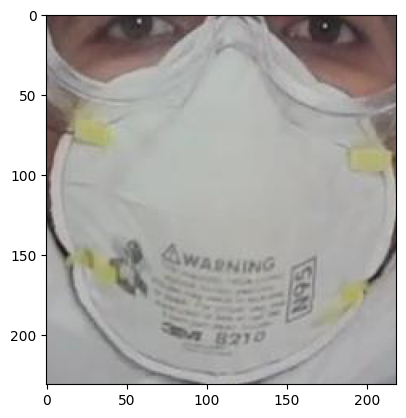

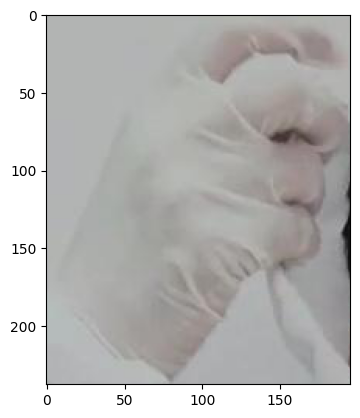

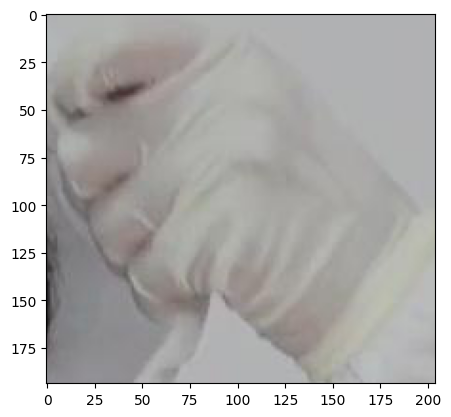

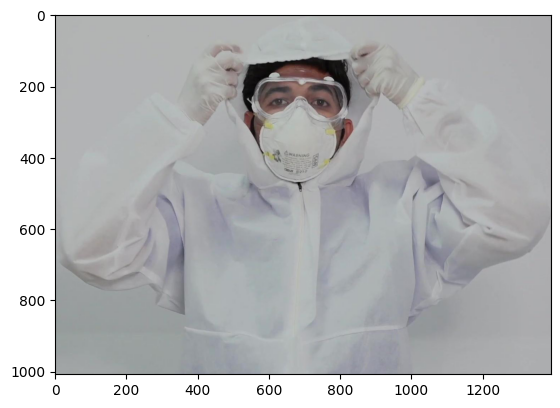

In [22]:
for cropped_image in cropped_images:
    plt.imshow(cropped_image)
    plt.show()

In [23]:
text = None
device = "cuda"
inputs = processor(images=search_image_1, text=text, semantics=cropped_images, return_tensors="pt", padding=True).to(device)

In [24]:
inputs['input_semantics'].shape

torch.Size([5, 3, 224, 224])

In [16]:
modelfile_path = "/mnt/nas2/users/sbchoi/transformers/examples/research_projects/groundingdino2/grounding-dino-tiny-finetuned-cppe-5-10k-steps-no-trainer/"
model = GroundingDino2ForObjectDetection.from_pretrained(modelfile_path, ignore_mismatched_sizes=True).to(device)

/opt/conda/lib/python3.10/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


In [25]:
output = model(**inputs)

In [26]:
results = processor.post_process_grounded_object_detection_v2(
    output,
    box_threshold=0.15,
    target_sizes=[search_image_1.size[::-1]]
)[0]
print(results)

{'scores': tensor([0.2711, 0.1851, 0.1810, 0.1638], device='cuda:0',
       grad_fn=<IndexBackward0>), 'boxes': tensor([[136.8738,   3.3247, 304.2327, 203.3449],
        [  0.8276,  26.5154, 162.0381, 204.3370],
        [172.9294,  26.7022, 214.2876,  78.7876],
        [179.4366,  46.1036, 212.3118,  78.0149]], device='cuda:0',
       grad_fn=<IndexBackward0>), 'probs': tensor([[0.2687, 0.2706, 0.2707,  ..., 0.0000, 0.0000, 0.0000],
        [0.1845, 0.1849, 0.1848,  ..., 0.0000, 0.0000, 0.0000],
        [0.1800, 0.1808, 0.1808,  ..., 0.0000, 0.0000, 0.0000],
        [0.1630, 0.1636, 0.1636,  ..., 0.0000, 0.0000, 0.0000]],
       device='cuda:0', grad_fn=<IndexBackward0>)}


In [27]:
def plot_results(pil_img, scores, probs, boxes):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for score, prob, (xmin, ymin, xmax, ymax), c in zip(scores, probs, boxes, colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        label = f'{score:0.2f}'
        ax.text(xmin, ymin, label, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

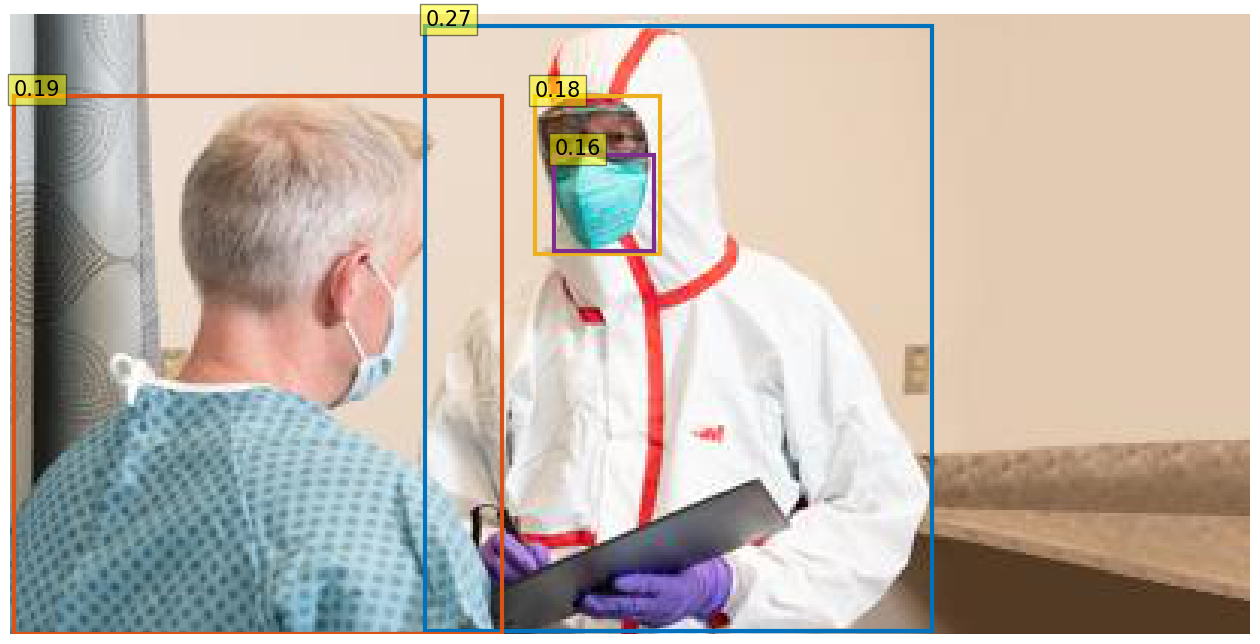

In [28]:
plot_results(search_image_1, results['scores'].detach().cpu(), results['probs'].detach().cpu(), results['boxes'].detach().cpu().numpy())